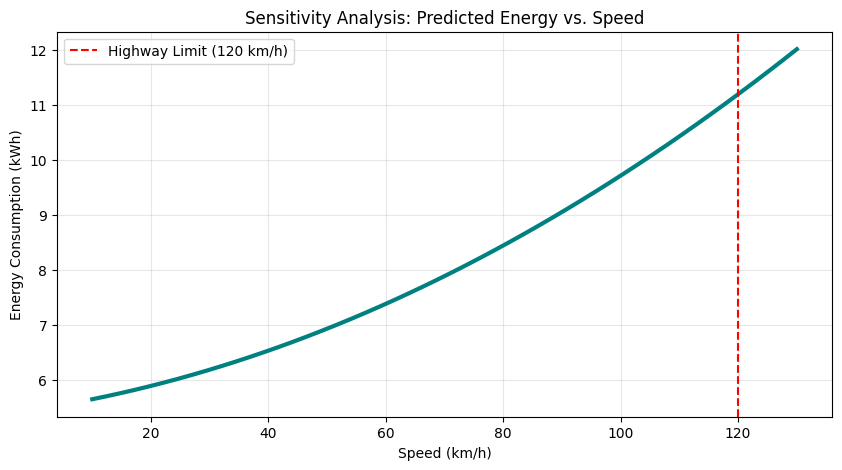

--- Final System Insights ---
Avg Efficiency: 87.27 kWh/100km
Avg CO2 Impact: 34.91 kg CO2/100km


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import sys
import os

# setup paths and load logic
sys.path.append(os.path.abspath('../src'))
from features import calculate_efficiency_metrics, calculate_carbon_footprint

# load the trained model and the specific column order it expects
model = joblib.load('../models/ev_model.pkl')
model_cols = joblib.load('../models/model_columns.pkl')

# load the engineered data (the one before dummy encoding)
# this is usually the 'processed_engineered.csv' saved in notebook 1
df_eng = pd.read_csv('../data/processed_engineered.csv')

# sensitivity analysis: speed vs energy
# ---------------------------------------------------------
speeds = np.linspace(10, 130, 50)
sim_results = []

# select a "baseline" trip to modify (e.g., trip index 10)
# use the raw engineered data and then preprocess it to get the right format
from preprocessing import preprocess_data
df_processed = preprocess_data(df_eng)

baseline_row = df_processed.iloc[[10]].copy()

for s in speeds:
    # create a fresh copy of the baseline for this specific speed
    temp_df = baseline_row.copy()
    
    # update physics-based variables for the new speed 's'
    v_ms = s / 3.6
    temp_df['Drag_Proxy'] = v_ms**2
    temp_df['Thermal_Stress_Index'] = temp_df['Battery_Temperature_C'] * v_ms
    temp_df['Incline_Work_Proxy'] = temp_df['Vehicle_Weight_kg'] * v_ms * (temp_df['Slope_%'] / 100)
    
    # ensure to only pass the columns the model was trained on, in the right order
    input_data = temp_df[model_cols]
    
    # predict and store
    pred = model.predict(input_data)[0]
    sim_results.append(pred)

# visualise teh curve
# 
plt.figure(figsize=(10, 5))
plt.plot(speeds, sim_results, color='teal', linewidth=3)
plt.axvline(x=120, color='red', linestyle='--', label='Highway Limit (120 km/h)')
plt.title("Sensitivity Analysis: Predicted Energy vs. Speed")
plt.xlabel("Speed (km/h)")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# fleet impact analysis
# ---------------------------------------------------------
df_metrics = calculate_efficiency_metrics(df_eng)
df_final = calculate_carbon_footprint(df_metrics)

print(f"--- Final System Insights ---")
print(f"Avg Efficiency: {df_final['kWh_per_100km'].mean():.2f} kWh/100km")
print(f"Avg CO2 Impact: {df_final['CO2_per_100km'].mean():.2f} kg CO2/100km")